## Brain Tumor Classification From MRI Scans

This assignment implements a complete pipeline for brain tumor detection and
segmentation from MRI scans. We explore multiple deep learning architectures and
compare their performance using clinical metrics The work demonstrates proper
medical image preprocessing, data augmentation strategies, and clinical
evaluation methodologies.

DATASET:
Brain Tumor MRI Dataset from Kaggle
- 4 classes: Glioma, Meningioma, Pituitary Tumor, No Tumor
- ~7000 MRI images across train/test splits
- Grayscale images of varying dimensions

LEARNING OBJECTIVES:
1. Understand medical image preprocessing and normalization
2. Implement multiple CNN architectures from scratch and via transfer learning
3. Apply proper data augmentation for medical imaging
4. Evaluate models using clinical metrics (sensitivity, specificity, AUC)
5. Interpret model decisions using Grad-CAM visualization
6. Compare architectural choices and their trade-offs

In [ ]:
print("=" * 80)
print("SECTION 1: ENVIRONMENT SETUP")
print("=" * 80)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    roc_auc_score, accuracy_score, precision_recall_fscore_support
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import cv2
import os
import warnings
from tqdm.notebook import tqdm
import time
from collections import Counter

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")
print(f"✓ TensorFlow version: {tf.__version__}")
print(f"✓ GPU Available: {tf.config.list_physical_devices('GPU')}")
print()

SECTION 1: ENVIRONMENT SETUP
✓ Libraries imported successfully
✓ TensorFlow version: 2.19.0
✓ GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]



In [ ]:


from google.colab import files

uploaded = files.upload()

old_name = next(iter(uploaded))
new_name = "brain-tumor-mri-dataset.zip"

if not os.path.exists(new_name):
    os.rename(old_name, new_name)
else:
    print("File already exists!")


TypeError: 'NoneType' object is not subscriptable

Medical imaging preprocessing is crucial for model performance. According to
Menze et al. (2015) in the BraTS challenge paper, standardization across
different MRI scanners and protocols requires:
1. Intensity normalization (z-score or min-max)
2. Skull stripping (when working with raw DICOM)
3. Registration to common anatomical template
4. Resampling to consistent resolution

For this assignment, we'll focus on intensity normalization and augmentation
since our dataset is already preprocessed.

In [ ]:
print("📥 Extracting dataset from uploaded zip file...")
print("Note: If file not found, please upload brain-tumor-mri-dataset.zip to Colab")
print()

import os
import zipfile

# Define potential zip file paths
zip_path = 'brain-tumor-mri-dataset.zip'
uploaded_zip_path = 'brain-tumor-mri-dataset (1).zip'

actual_zip_to_extract = None

if os.path.exists(zip_path):
    actual_zip_to_extract = zip_path
elif os.path.exists(uploaded_zip_path):
    print(f"Found {uploaded_zip_path}, using it for extraction.")
    actual_zip_to_extract = uploaded_zip_path
else:
    print(f"Neither {zip_path} nor {uploaded_zip_path} found!")
    print()
    print("  1. Download from: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset")

if actual_zip_to_extract:
    print(f"✓ Found {actual_zip_to_extract}")
    print("  Extracting...")
    with zipfile.ZipFile(actual_zip_to_extract, 'r') as zip_ref:
        zip_ref.extractall('brain_tumor_data')
    print("✓ Dataset extracted successfully!")

print()

📥 Extracting dataset from uploaded zip file...
Note: If file not found, please upload brain-tumor-mri-dataset.zip to Colab

✓ Found brain-tumor-mri-dataset.zip
  Extracting...
✓ Dataset extracted successfully!



In [ ]:
DATA_DIR = 'brain_tumor_data'
TRAIN_DIR = os.path.join(DATA_DIR, 'Training')
TEST_DIR = os.path.join(DATA_DIR, 'Testing')

# Image parameters
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32
NUM_CLASSES = 4
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

EXPLORATORY DATA ANALYSIS
-------------------------
Understanding the dataset is critical before modeling. We need to:
1. Check class distribution (potential imbalance)
2. Analyze image dimensions and quality
3. Visualize sample images from each class
4. Identify preprocessing requirements

Training Set Distribution:
  glioma         : 1400 images
  meningioma     : 1400 images
  notumor        : 1400 images
  pituitary      : 1400 images
  TOTAL          : 5600 images

Testing Set Distribution:
  glioma         :  400 images
  meningioma     :  400 images
  notumor        :  400 images
  pituitary      :  400 images
  TOTAL          : 1600 images



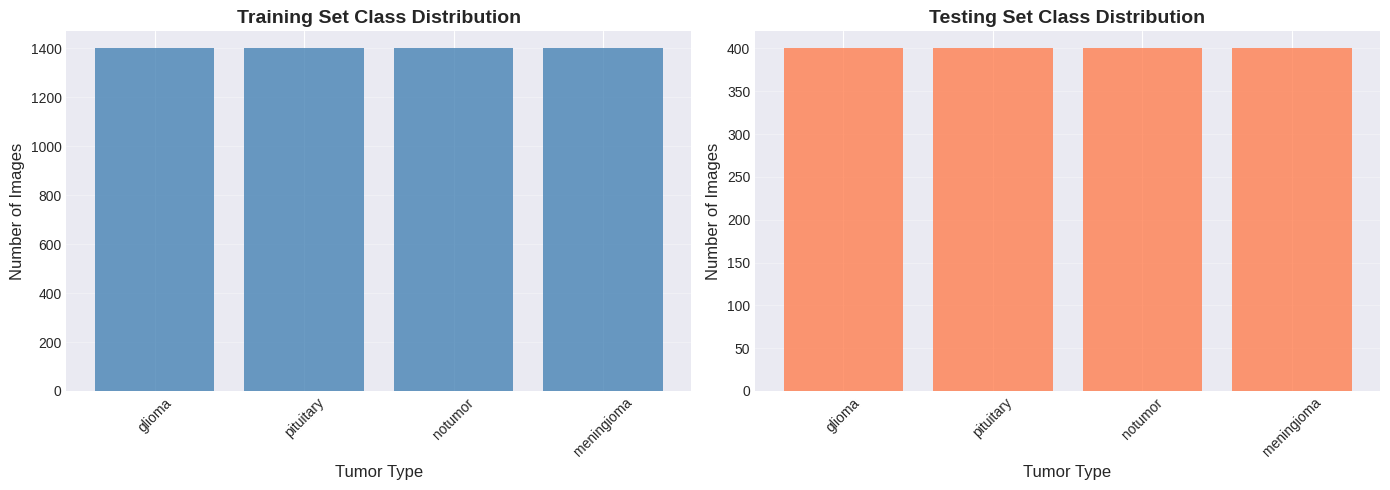

📊 Observation: Check if classes are balanced or if we need class weights



In [ ]:
def count_images_per_class(data_dir):
    """Count images in each class directory"""
    class_counts = {}
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            count = len([f for f in os.listdir(class_path)
                        if f.endswith(('.jpg', '.png', '.jpeg'))])
            class_counts[class_name] = count
    return class_counts

train_counts = count_images_per_class(TRAIN_DIR)
test_counts = count_images_per_class(TEST_DIR)

print("Training Set Distribution:")
for class_name, count in sorted(train_counts.items()):
    print(f"  {class_name:15s}: {count:4d} images")
print(f"  {'TOTAL':15s}: {sum(train_counts.values()):4d} images")
print()

print("Testing Set Distribution:")
for class_name, count in sorted(test_counts.items()):
    print(f"  {class_name:15s}: {count:4d} images")
print(f"  {'TOTAL':15s}: {sum(test_counts.values()):4d} images")
print()

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training distribution
axes[0].bar(train_counts.keys(), train_counts.values(), color='steelblue', alpha=0.8)
axes[0].set_title('Training Set Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tumor Type', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Testing distribution
axes[1].bar(test_counts.keys(), test_counts.values(), color='coral', alpha=0.8)
axes[1].set_title('Testing Set Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tumor Type', fontsize=12)
axes[1].set_ylabel('Number of Images', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("📊 Observation: Check if classes are balanced or if we need class weights")
print()

CLINICAL INSIGHT 1: Class Imbalance
------------------------------------
In medical imaging, class imbalance is common and clinically significant:
- Rare tumors may have fewer samples
- "No tumor" cases might be overrepresented in screening datasets
- Imbalance requires special handling: class weights, focal loss, or SMOTE

We'll compute class weights to handle this during training.


 Data Augmentation in Medical Imaging
---------------------------------------------------------------
Data augmentation is crucial but must be clinically appropriate:
- Rotation: ✓ (brain orientation can vary in imaging)
- Horizontal flip: ✓ (left/right hemisphere)
- Vertical flip: ✗ (not anatomically realistic)
- Zoom/scaling: ✓ (different tumor sizes)
- Brightness/contrast: ✓ (scanner variations)
- Extreme distortions: ✗ (unrealistic artifacts)

Reference: Shorten & Khoshgoftaar (2019) - "A survey on Image Data Augmentation
for Deep Learning" emphasizes domain-specific augmentation strategies.
"""

🔄 Setting up data augmentation pipeline...
Found 4760 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
✓ Training samples: 4760
✓ Validation samples: 840
✓ Test samples: 1600
✓ Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

📸 Visualizing augmentation effects...


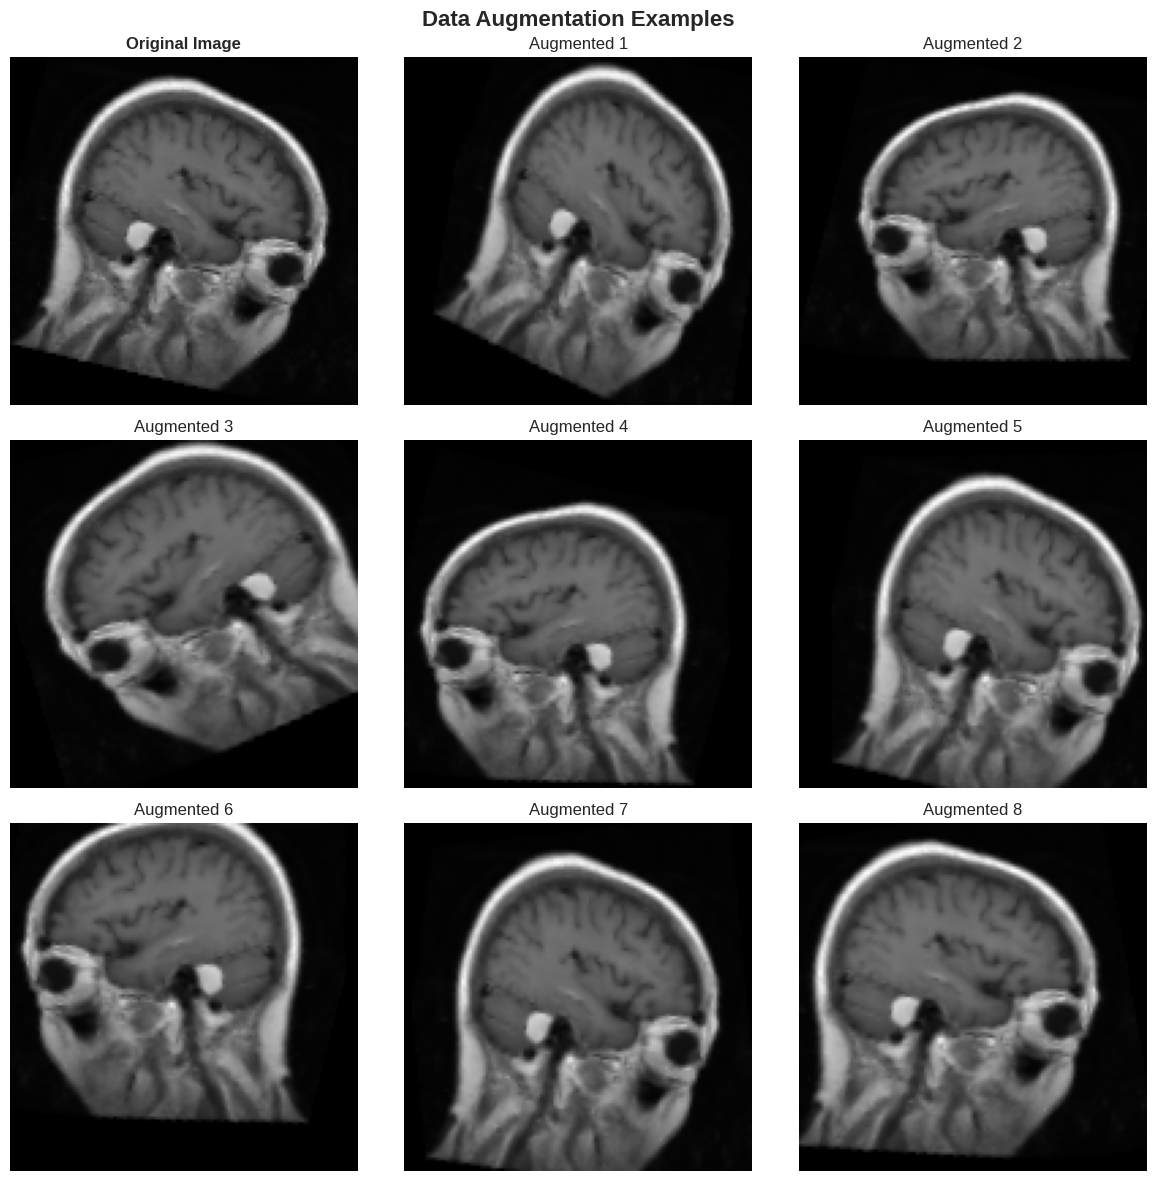

✓ Augmentation visualization complete

⚖️ Computing class weights for imbalanced data...
Class weights:
  glioma         : 1.000
  meningioma     : 1.000
  notumor        : 1.000
  pituitary      : 1.000



In [ ]:
print("🔄 Setting up data augmentation pipeline...")

# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,                    # Normalize to [0,1]
    rotation_range=15,                 # Random rotation ±15°
    width_shift_range=0.1,             # Horizontal shift
    height_shift_range=0.1,            # Vertical shift
    shear_range=0.1,                   # Shear transformation
    zoom_range=0.15,                   # Random zoom
    horizontal_flip=True,              # Random horizontal flip
    fill_mode='constant',              # Fill with zeros
    cval=0,                            # Fill value
    validation_split=0.15              # 15% for validation
)

# Test data generator (only rescaling, no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load training data with augmentation
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=True,
    subset='training',
    seed=42
)

# Load validation data (from training split, no augmentation in validation)
validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=False,
    subset='validation',
    seed=42
)

# Load test data
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=False
)

print(f"✓ Training samples: {train_generator.samples}")
print(f"✓ Validation samples: {validation_generator.samples}")
print(f"✓ Test samples: {test_generator.samples}")
print(f"✓ Class indices: {train_generator.class_indices}")
print()
print("📸 Visualizing augmentation effects...")

sample_batch = next(iter(train_generator))
original_image = sample_batch[0][0]  # First image from batch

# Generate augmented versions
augmented_images = []
temp_gen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='constant'
)

# Create multiple augmented versions
img_array = np.expand_dims(original_image, 0)
aug_iter = temp_gen.flow(img_array * 255, batch_size=1)  # Rescale back
for i in range(8):
    aug_img = next(aug_iter)[0].astype('uint8')
    augmented_images.append(aug_img)

# Plot original and augmented
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('Data Augmentation Examples', fontsize=16, fontweight='bold')

axes[0, 0].imshow(original_image.squeeze(), cmap='gray')
axes[0, 0].set_title('Original Image', fontweight='bold')
axes[0, 0].axis('off')

for idx, aug_img in enumerate(augmented_images):
    row = (idx + 1) // 3
    col = (idx + 1) % 3
    axes[row, col].imshow(aug_img.squeeze(), cmap='gray')
    axes[row, col].set_title(f'Augmented {idx+1}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Augmentation visualization complete")
print()

# Compute class weights for handling imbalance
print("⚖️ Computing class weights for imbalanced data...")

class_counts_array = np.array([train_counts[cn] for cn in sorted(CLASS_NAMES)])
total_samples = np.sum(class_counts_array)
class_weights = total_samples / (NUM_CLASSES * class_counts_array)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print("Class weights:")
for i, (class_name, weight) in enumerate(zip(sorted(CLASS_NAMES), class_weights)):
    print(f"  {class_name:15s}: {weight:.3f}")
print()

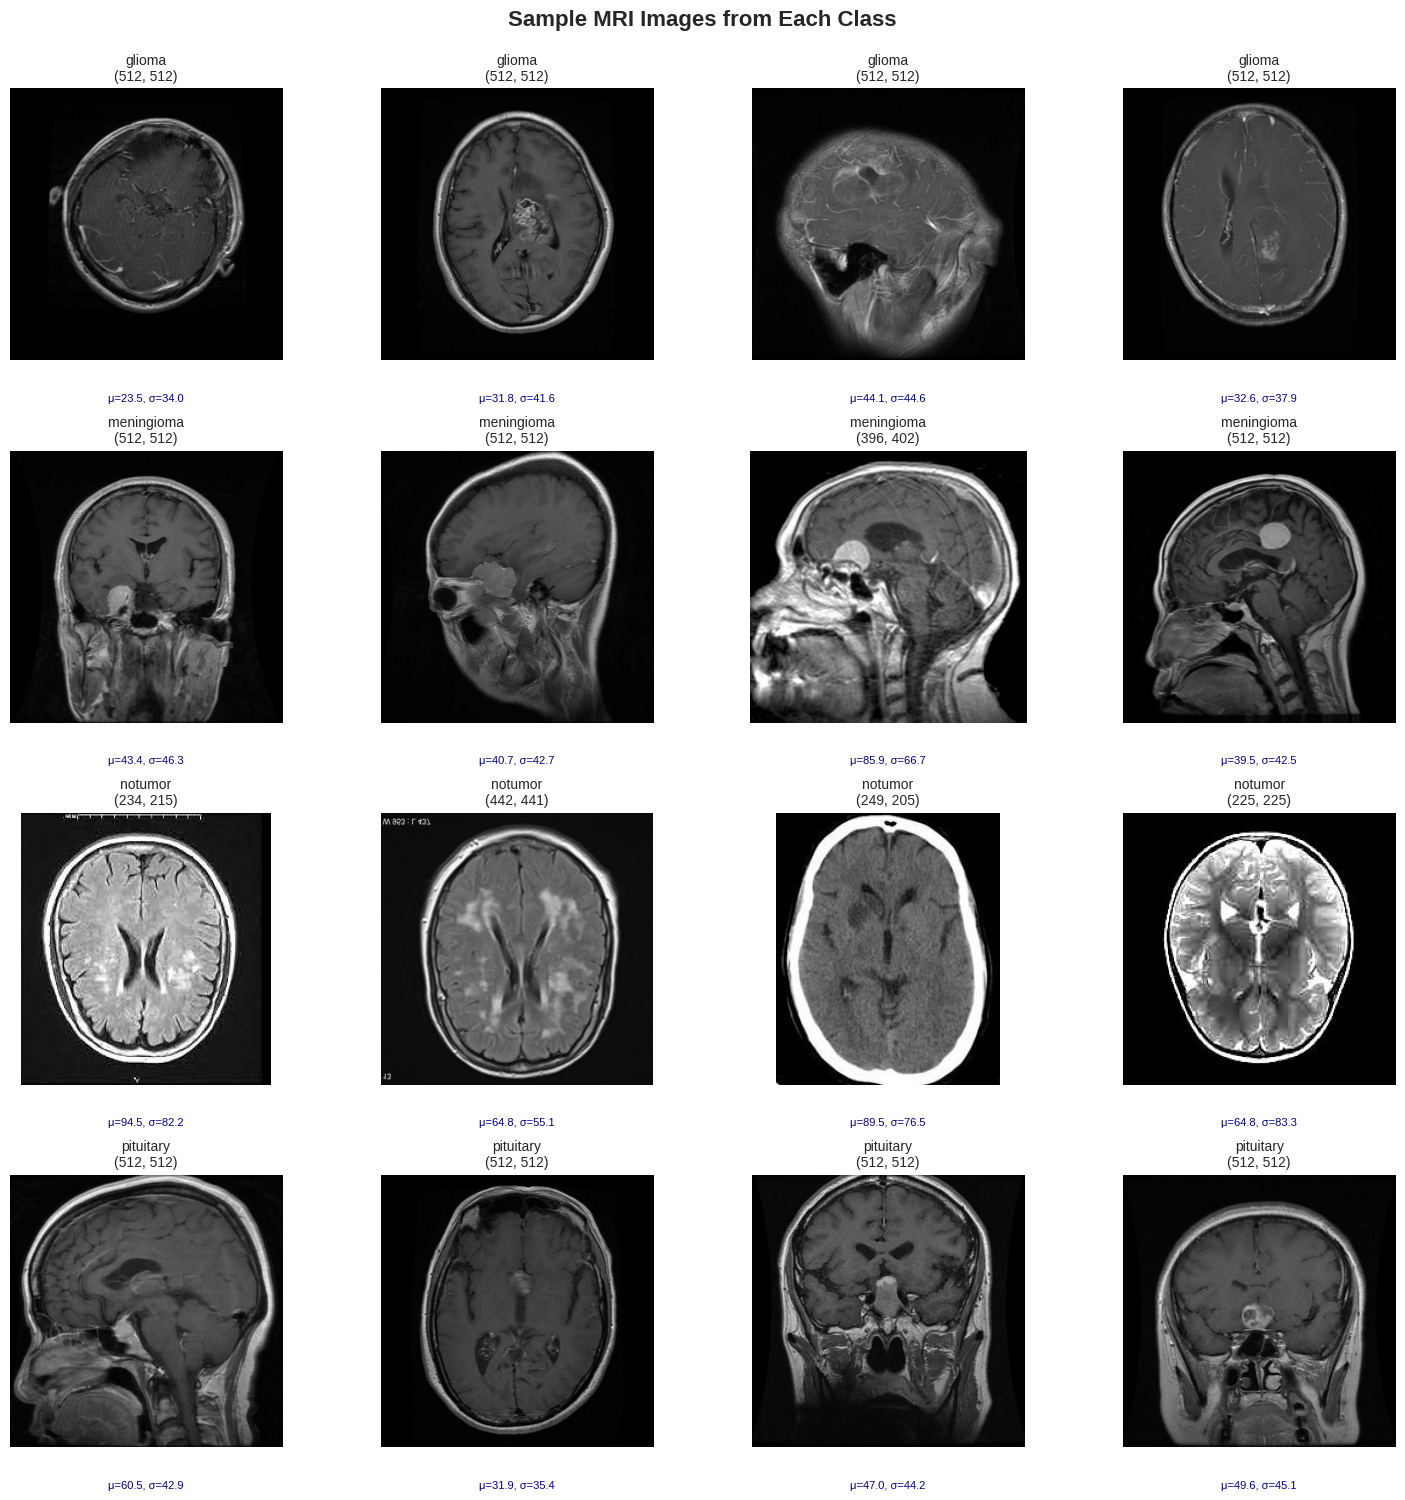

🔍 Key Observations:
  - Image dimensions vary (need resizing)
  - Intensity ranges differ (need normalization)
  - Different contrast levels (augmentation will help)

📏 Analyzing image dimensions (sampling 200 images)...
  Found 43 unique dimensions (from sample)
  Most common dimensions:
    (512, 512): 4012 images
    (225, 225): 253 images
    (630, 630): 69 images
    (251, 201): 40 images
    (236, 236): 39 images
  → Standardizing to 128x128 for consistent processing



In [ ]:
# Display sample images from each class
def load_sample_images(data_dir, samples_per_class=3):
    """Load sample images from each class"""
    samples = {}
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            image_files = [f for f in os.listdir(class_path)
                          if f.endswith(('.jpg', '.png', '.jpeg'))]
            sample_files = np.random.choice(image_files,
                                           min(samples_per_class, len(image_files)),
                                           replace=False)
            images = []
            for img_file in sample_files:
                img_path = os.path.join(class_path, img_file)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                images.append(img)
            samples[class_name] = images
    return samples

sample_images = load_sample_images(TRAIN_DIR, samples_per_class=4)

# Plot sample images
fig, axes = plt.subplots(4, 4, figsize=(15, 15))
fig.suptitle('Sample MRI Images from Each Class', fontsize=16, fontweight='bold', y=0.995)

for idx, (class_name, images) in enumerate(sorted(sample_images.items())):
    for i, img in enumerate(images):
        axes[idx, i].imshow(img, cmap='gray')
        axes[idx, i].set_title(f'{class_name}\n{img.shape}', fontsize=10)
        axes[idx, i].axis('off')

        # Add simple statistics
        mean_intensity = np.mean(img)
        std_intensity = np.std(img)
        axes[idx, i].text(0.5, -0.15, f'μ={mean_intensity:.1f}, σ={std_intensity:.1f}',
                         transform=axes[idx, i].transAxes,
                         ha='center', fontsize=8, color='darkblue')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=300, bbox_inches='tight')
plt.show()

print("🔍 Key Observations:")
print("  - Image dimensions vary (need resizing)")
print("  - Intensity ranges differ (need normalization)")
print("  - Different contrast levels (augmentation will help)")
print()

def analyze_image_dimensions(data_dir):
    """Analyze distribution of image dimensions"""
    dimensions = []
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            for img_file in os.listdir(class_path):
                if img_file.endswith(('.jpg', '.png', '.jpeg')):
                    img_path = os.path.join(class_path, img_file)
                    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    dimensions.append(img.shape)
    return dimensions

print("📏 Analyzing image dimensions (sampling 200 images)...")
all_dims = analyze_image_dimensions(TRAIN_DIR)
sampled_dims = np.random.choice(len(all_dims), min(200, len(all_dims)), replace=False)
unique_dims = set([all_dims[i] for i in sampled_dims])

print(f"  Found {len(unique_dims)} unique dimensions (from sample)")
print(f"  Most common dimensions:")
dim_counter = Counter(all_dims)
for dim, count in dim_counter.most_common(5):
    print(f"    {dim}: {count} images")
print(f"  → Standardizing to {IMG_HEIGHT}x{IMG_WIDTH} for consistent processing")
print()

In [ ]:
# ============================================================
# TRANSFER LEARNING DATA PIPELINE (RGB + MobileNetV2 preprocess)
# ============================================================

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print("🔄 Setting up TRANSFER LEARNING generators (RGB + preprocess_input)...")

# IMPORTANT:
# - Do NOT use rescale=1./255 when using preprocess_input for MobileNetV2.
# - preprocess_input expects raw pixels in [0, 255] and normalizes internally.

train_datagen_tl = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='constant',
    cval=0,
    validation_split=0.15
)

test_datagen_tl = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator_tl = train_datagen_tl.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb',         # <-- key difference vs baseline
    shuffle=True,
    subset='training',
    seed=1
)

validation_generator_tl = train_datagen_tl.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    subset='validation',
    seed=1
)

test_generator_tl = test_datagen_tl.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

print(f"✓ TL Training samples: {train_generator_tl.samples}")
print(f"✓ TL Validation samples: {validation_generator_tl.samples}")
print(f"✓ TL Test samples: {test_generator_tl.samples}")
print(f"✓ TL Class indices: {train_generator_tl.class_indices}")
print()

# Sanity check: class order should match baseline (so comparisons are valid)
assert train_generator.class_indices == train_generator_tl.class_indices, \
    "Class index mapping differs between baseline and TL generators."
print("✓ Class index mapping matches baseline.")


🔄 Setting up TRANSFER LEARNING generators (RGB + preprocess_input)...
Found 4760 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
✓ TL Training samples: 4760
✓ TL Validation samples: 840
✓ TL Test samples: 1600
✓ TL Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

✓ Class index mapping matches baseline.


 Why Class Weights Matter
---------------------------------------------
In clinical applications, misclassifying a tumor (false negative) is often
more dangerous than a false positive. Class weights help the model pay more
attention to minority classes, reducing the risk of missing rare tumors.

Alternative approaches: Focal Loss (Lin et al. 2017), Cost-sensitive learning
"""

 Building a Baseline CNN
----------------------------------------------------
We start with a custom CNN to understand fundamental concepts:
1. Convolutional layers: Feature extraction
2. Batch normalization: Training stability
3. Max pooling: Dimension reduction, translation invariance
4. Dropout: Regularization to prevent overfitting
5. Dense layers: Classification

This baseline will be compared against transfer learning models.

In [ ]:
def create_baseline_cnn(input_shape=(IMG_HEIGHT, IMG_WIDTH, 1), num_classes=NUM_CLASSES):
    """
    Creates a baseline CNN architecture for brain tumor classification.

    Architecture:
    - 3 Convolutional blocks (Conv2D -> BatchNorm -> ReLU -> MaxPool -> Dropout)
    - Progressive filter increase: 32 -> 64 -> 128
    - Global Average Pooling
    - Dense layers with dropout
    - Softmax output
    """
    model = models.Sequential([
        # Input layer
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Block 4 - Deeper features
        layers.Conv2D(256, (3, 3), padding='same', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.GlobalAveragePooling2D(),  # Better than Flatten

        # Dense layers
        layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
        layers.Dropout(0.4),

        # Output layer
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Create and compile baseline model
print("🏗️ Building baseline CNN...")
baseline_model = create_baseline_cnn()

baseline_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

print("✓ Baseline model created")
print()
print("Model Architecture:")
baseline_model.summary()
print()

# Calculate model parameters
total_params = baseline_model.count_params()
print(f"📊 Total parameters: {total_params:,}")
print(f"📊 Trainable parameters: {total_params:,}")
print()

🏗️ Building baseline CNN...
✓ Baseline model created

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             

 Total params: 431,684 (1.65 MB)

 Trainable params: 430,468 (1.64 MB)

 Non-trainable params: 1,216 (4.75 KB)


📊 Total parameters: 431,684
📊 Trainable parameters: 431,684



TRAINING STRATEGY
-----------------
We use several callbacks to optimize training:
1. EarlyStopping: Prevent overfitting
2. ReduceLROnPlateau: Adaptive learning rate
3. ModelCheckpoint: Save best model

These are standard practices in medical imaging (Raghu et al. 2019)
"""

🚀 Training baseline CNN...
Note: Training on CPU may take 20-30 minutes per epoch
      Reducing epochs to 15 for reasonable runtime

Epoch 1/2
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.5138 - loss: 1.2718 - precision: 0.5740 - recall: 0.3949
Epoch 1: val_accuracy improved from None to 0.27143, saving model to baseline_best_model.keras

Epoch 1: finished saving model to baseline_best_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 38s 173ms/step - accuracy: 0.5748 - loss: 1.0824 - precision: 0.6521 - recall: 0.4544 - val_accuracy: 0.2714 - val_loss: 2.8797 - val_precision: 0.2753 - val_recall: 0.2619 - learning_rate: 0.0010
Epoch 2/2
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.6475 - loss: 0.8784 - precision: 0.7260 - recall: 0.5349
Epoch 2: val_accuracy improved from 0.27143 to 0.41071, saving model to baseline_best_model.keras

Epoch 2: finished saving model to baseline_best_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 16s 105ms/step - accuracy: 0.6542 - loss: 0.8693 

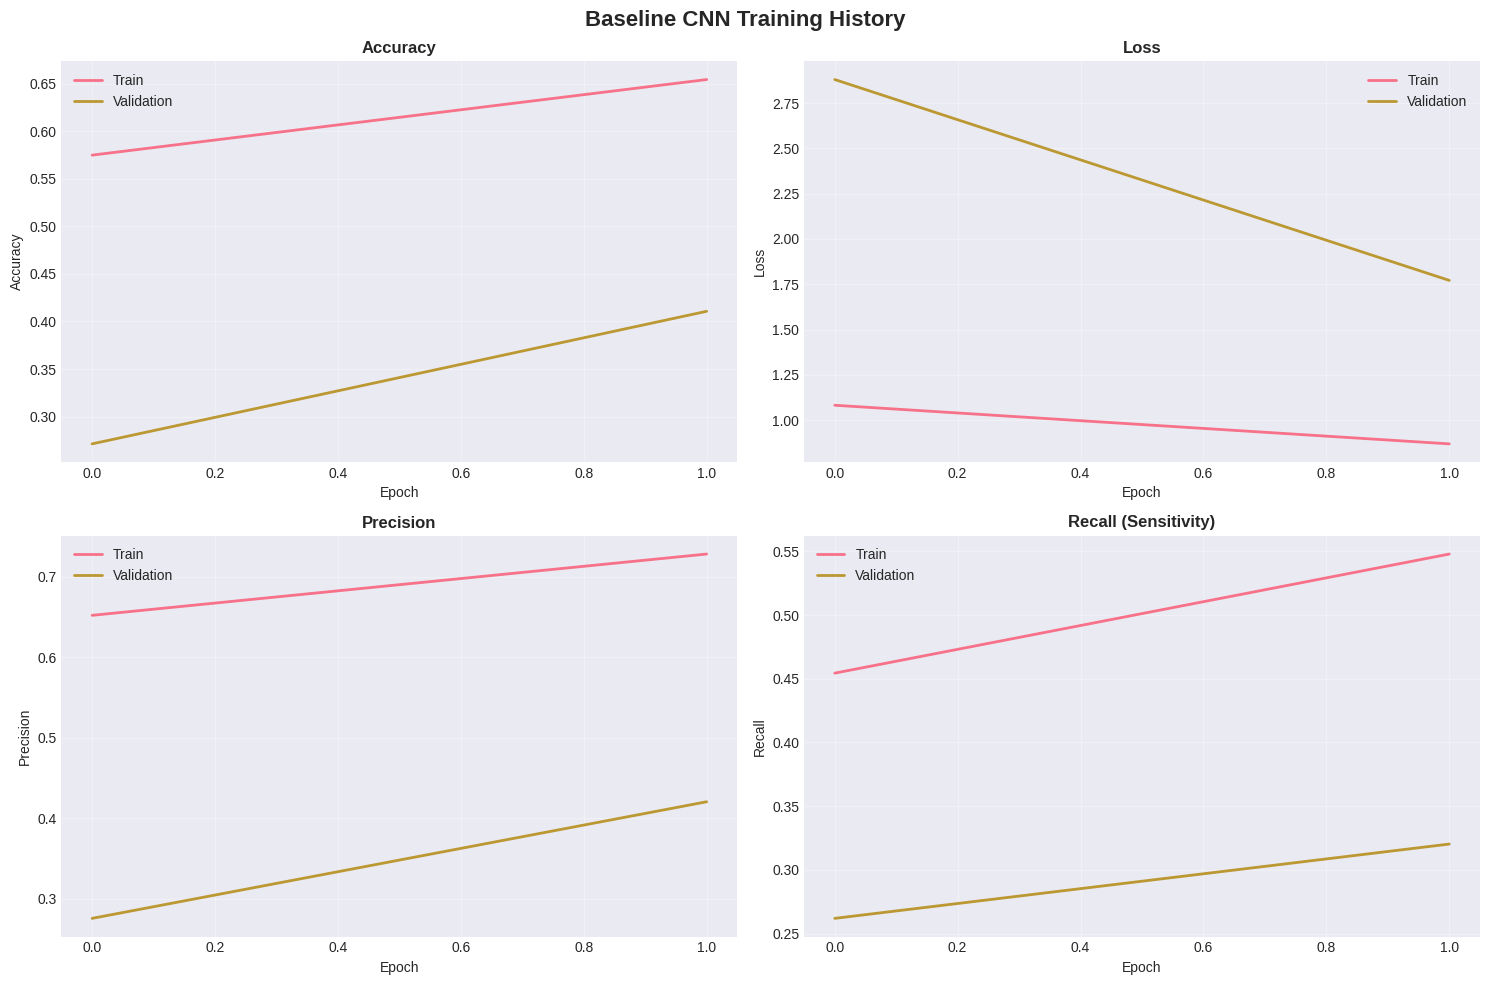

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'baseline_best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("🚀 Training baseline CNN...")
print("Note: Training on CPU may take 20-30 minutes per epoch")
print("      Reducing epochs to 15 for reasonable runtime")
print()

# Train the model
EPOCHS = 2  # Reduced for CPU training

history_baseline = baseline_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print("✓ Baseline model training complete!")
print()

# Plot training history
def plot_training_history(history, model_name="Model"):
    """Plot training and validation metrics"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'{model_name} Training History', fontsize=16, fontweight='bold')

    # Accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Train', linewidth=2)
    axes[0, 0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    axes[0, 0].set_title('Accuracy', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # Loss
    axes[0, 1].plot(history.history['loss'], label='Train', linewidth=2)
    axes[0, 1].plot(history.history['val_loss'], label='Validation', linewidth=2)
    axes[0, 1].set_title('Loss', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # Precision
    axes[1, 0].plot(history.history['precision'], label='Train', linewidth=2)
    axes[1, 0].plot(history.history['val_precision'], label='Validation', linewidth=2)
    axes[1, 0].set_title('Precision', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    # Recall
    axes[1, 1].plot(history.history['recall'], label='Train', linewidth=2)
    axes[1, 1].plot(history.history['val_recall'], label='Validation', linewidth=2)
    axes[1, 1].set_title('Recall (Sensitivity)', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{model_name.lower()}_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history_baseline, "Baseline CNN")


## Transfer Learning: Data Pipeline and Preprocessing

While the baseline CNN operates on grayscale medical images, most modern pretrained convolutional networks are trained on large-scale RGB datasets such as ImageNet. To enable transfer learning, we therefore construct a separate data pipeline that:

- Loads images in **RGB format (3 channels)**  
- Applies medically appropriate **data augmentation**  
- Uses the backbone-specific **preprocessing function** required by the pretrained model  

In this notebook, MobileNetV2 is used as the transfer learning backbone. Its `preprocess_input` function normalizes pixel values in a manner consistent with ImageNet training, and thus replaces the simple rescaling used in the baseline pipeline.

To ensure a fair comparison, the class index mapping is preserved across baseline and transfer learning generators.


In [ ]:
# ============================================================
# TRANSFER LEARNING MODEL: MobileNetV2 (ImageNet pretrained)
# ============================================================

def create_mobilenetv2_transfer_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=NUM_CLASSES):
    """
    MobileNetV2 backbone + lightweight classification head.
    Phase 1: freeze backbone (train head)
    Phase 2: fine-tune last N layers
    """
    base = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False  # phase 1: frozen

    inputs = layers.Input(shape=input_shape)
    x = base(inputs, training=False)

    # Head (keep it light for CPU/Colab)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name="MobileNetV2_Transfer")
    return model, base

print("🏗️ Building MobileNetV2 transfer learning model...")
tl_model, tl_backbone = create_mobilenetv2_transfer_model()

tl_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("✓ Transfer model created\n")
tl_model.summary()

# Parameter stats (trainable vs non-trainable)
trainable_params = int(np.sum([tf.keras.backend.count_params(w) for w in tl_model.trainable_weights]))
non_trainable_params = int(np.sum([tf.keras.backend.count_params(w) for w in tl_model.non_trainable_weights]))
total_params = trainable_params + non_trainable_params

print(f"\n📊 Transfer Learning Parameter Stats")
print(f"  Total params:        {total_params:,}")
print(f"  Trainable params:    {trainable_params:,}")
print(f"  Non-trainable params:{non_trainable_params:,}")


🏗️ Building MobileNetV2 transfer learning model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ Transfer model created



Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


📊 Transfer Learning Parameter Stats
  Total params:        2,422,468
  Trainable params:    164,484
  Non-trainable params:2,257,984


## Transfer Learning Model Architecture

We now construct a transfer learning model using **MobileNetV2 pretrained on ImageNet** as a fixed feature extractor. MobileNetV2 is chosen due to its:

- Efficient depthwise separable convolutions  
- Strong representational capacity despite low parameter count  
- Proven performance in medical and low-resource imaging tasks  

The pretrained backbone is initially frozen to retain general visual features, while a lightweight task-specific classification head is trained on the medical dataset. We also explicitly report the number of **trainable vs non-trainable parameters**, enabling a direct comparison with the baseline CNN in terms of model capacity.

## Transfer Learning Training Strategy

Training is performed in two stages:

**Phase 1 – Frozen Backbone:**  
The pretrained MobileNetV2 backbone is frozen, and only the newly added classification head is trained. This allows the model to quickly adapt to the medical imaging task without disrupting learned low-level visual features.

**Phase 2 – Fine-Tuning:**  
In the second stage, the final layers of the backbone are selectively unfrozen and trained with a lower learning rate. This controlled fine-tuning enables the model to better specialize in domain-specific features while avoiding catastrophic forgetting.

Standard regularization techniques including early stopping, learning-rate scheduling, and class weighting are employed to improve generalization and handle class imbalance.
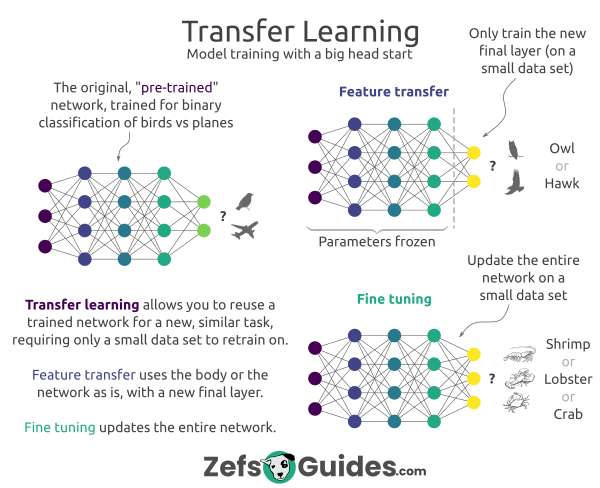

🚀 Training Transfer Learning model (Phase 1: frozen backbone)...
Epoch 1/2
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.6377 - loss: 0.9272 - precision: 0.6853 - recall: 0.5790
Epoch 1: val_accuracy improved from None to 0.87024, saving model to tl_mobilenetv2_best.keras

Epoch 1: finished saving model to tl_mobilenetv2_best.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 78s 404ms/step - accuracy: 0.7441 - loss: 0.6564 - precision: 0.7837 - recall: 0.7002 - val_accuracy: 0.8702 - val_loss: 0.3799 - val_precision: 0.8902 - val_recall: 0.8393 - learning_rate: 0.0010
Epoch 2/2
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.8312 - loss: 0.4335 - precision: 0.8578 - recall: 0.8054
Epoch 2: val_accuracy improved from 0.87024 to 0.87738, saving model to tl_mobilenetv2_best.keras

Epoch 2: finished saving model to tl_mobilenetv2_best.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 31s 208ms/step - accuracy: 0.8345 - loss: 0.4305 - precision: 0.8577 - recall: 0.8101 - val_accuracy: 0.8774 - val_lo

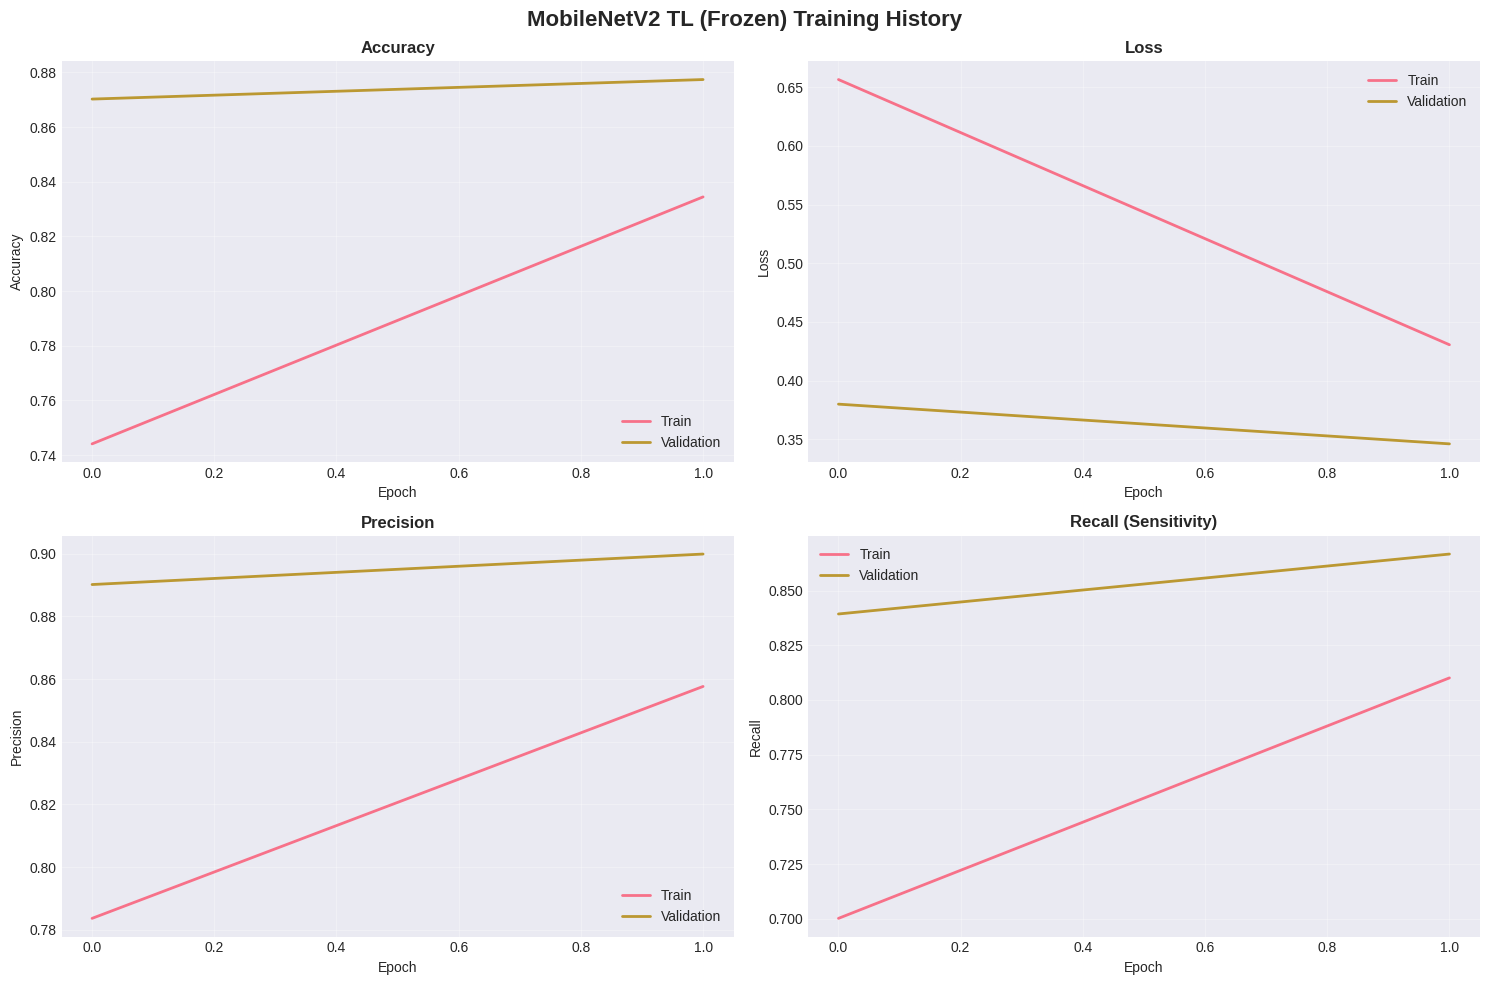


🔧 Fine-tuning: unfreezing last backbone layers...
📊 Fine-tune params: Trainable=1,846,020 | Non-trainable=576,448
🚀 Training Transfer Learning model (Phase 2: fine-tuning)...
Epoch 1/2
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.8241 - loss: 0.4768 - precision: 0.8448 - recall: 0.8025
Epoch 1: val_accuracy did not improve from 0.87738
149/149 ━━━━━━━━━━━━━━━━━━━━ 69s 330ms/step - accuracy: 0.8597 - loss: 0.3868 - precision: 0.8755 - recall: 0.8410 - val_accuracy: 0.8774 - val_loss: 0.3752 - val_precision: 0.8858 - val_recall: 0.8679 - learning_rate: 1.0000e-04
Epoch 2/2
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9073 - loss: 0.2380 - precision: 0.9165 - recall: 0.8977
Epoch 2: val_accuracy improved from 0.87738 to 0.88095, saving model to tl_mobilenetv2_best.keras

Epoch 2: finished saving model to tl_mobilenetv2_best.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 32s 213ms/step - accuracy: 0.9137 - loss: 0.2287 - precision: 0.9218 - recall: 0.9036 - val_accuracy: 0.881

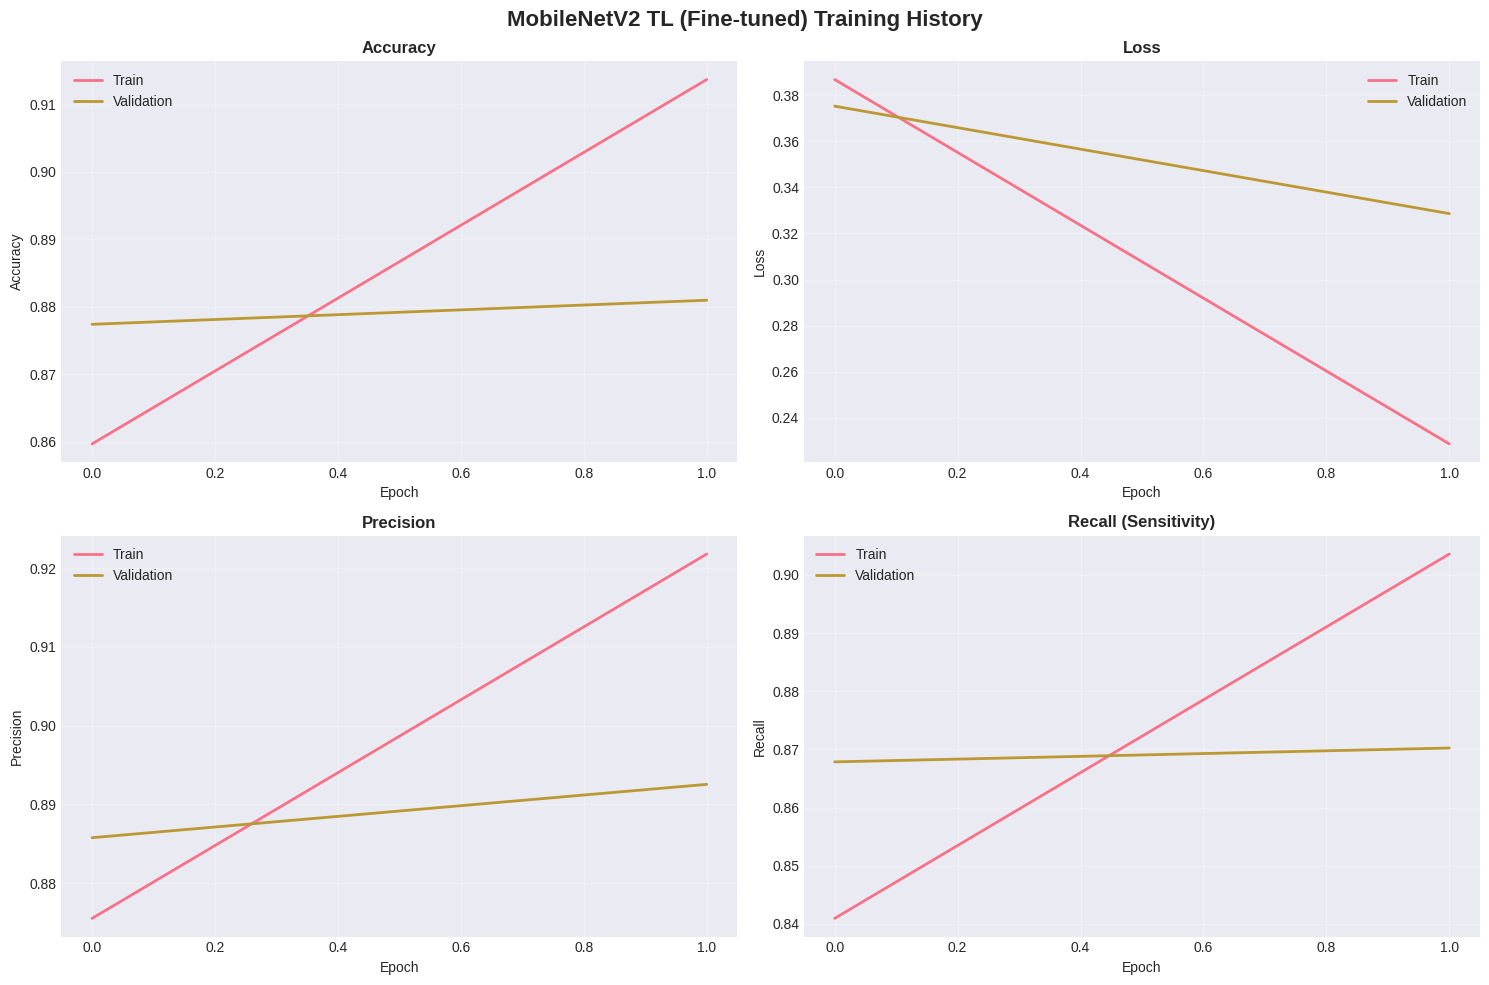

In [ ]:
# ============================================================
# TRAINING: Phase 1 (Frozen backbone)
# ============================================================

callbacks_tl = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint('tl_mobilenetv2_best.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

EPOCHS_TL_FROZEN = 2

print("🚀 Training Transfer Learning model (Phase 1: frozen backbone)...")
history_tl_frozen = tl_model.fit(
    train_generator_tl,
    validation_data=validation_generator_tl,
    epochs=EPOCHS_TL_FROZEN,
    callbacks=callbacks_tl,
    class_weight=class_weight_dict,
    verbose=1
)

plot_training_history(history_tl_frozen, model_name="MobileNetV2 TL (Frozen)")


# ============================================================
# TRAINING: Phase 2 (Fine-tune last layers)
# ============================================================

print("\n🔧 Fine-tuning: unfreezing last backbone layers...")

# Unfreeze backbone, then freeze early layers to avoid catastrophic forgetting
tl_backbone.trainable = True

# Tune this number if needed (higher = more trainable layers)
FINE_TUNE_AT = max(0, len(tl_backbone.layers) - 40)

for layer in tl_backbone.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# Use a smaller LR for fine-tuning
tl_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Updated parameter stats
trainable_params_ft = int(np.sum([tf.keras.backend.count_params(w) for w in tl_model.trainable_weights]))
non_trainable_params_ft = int(np.sum([tf.keras.backend.count_params(w) for w in tl_model.non_trainable_weights]))
print(f"📊 Fine-tune params: Trainable={trainable_params_ft:,} | Non-trainable={non_trainable_params_ft:,}")

EPOCHS_TL_FINETUNE = 2

print("🚀 Training Transfer Learning model (Phase 2: fine-tuning)...")
history_tl_finetune = tl_model.fit(
    train_generator_tl,
    validation_data=validation_generator_tl,
    epochs=EPOCHS_TL_FINETUNE,
    callbacks=callbacks_tl,
    class_weight=class_weight_dict,
    verbose=1
)

plot_training_history(history_tl_finetune, model_name="MobileNetV2 TL (Fine-tuned)")


## This section runs inference on a few test images and visualizes the model's predictions along with true labels and confidence.

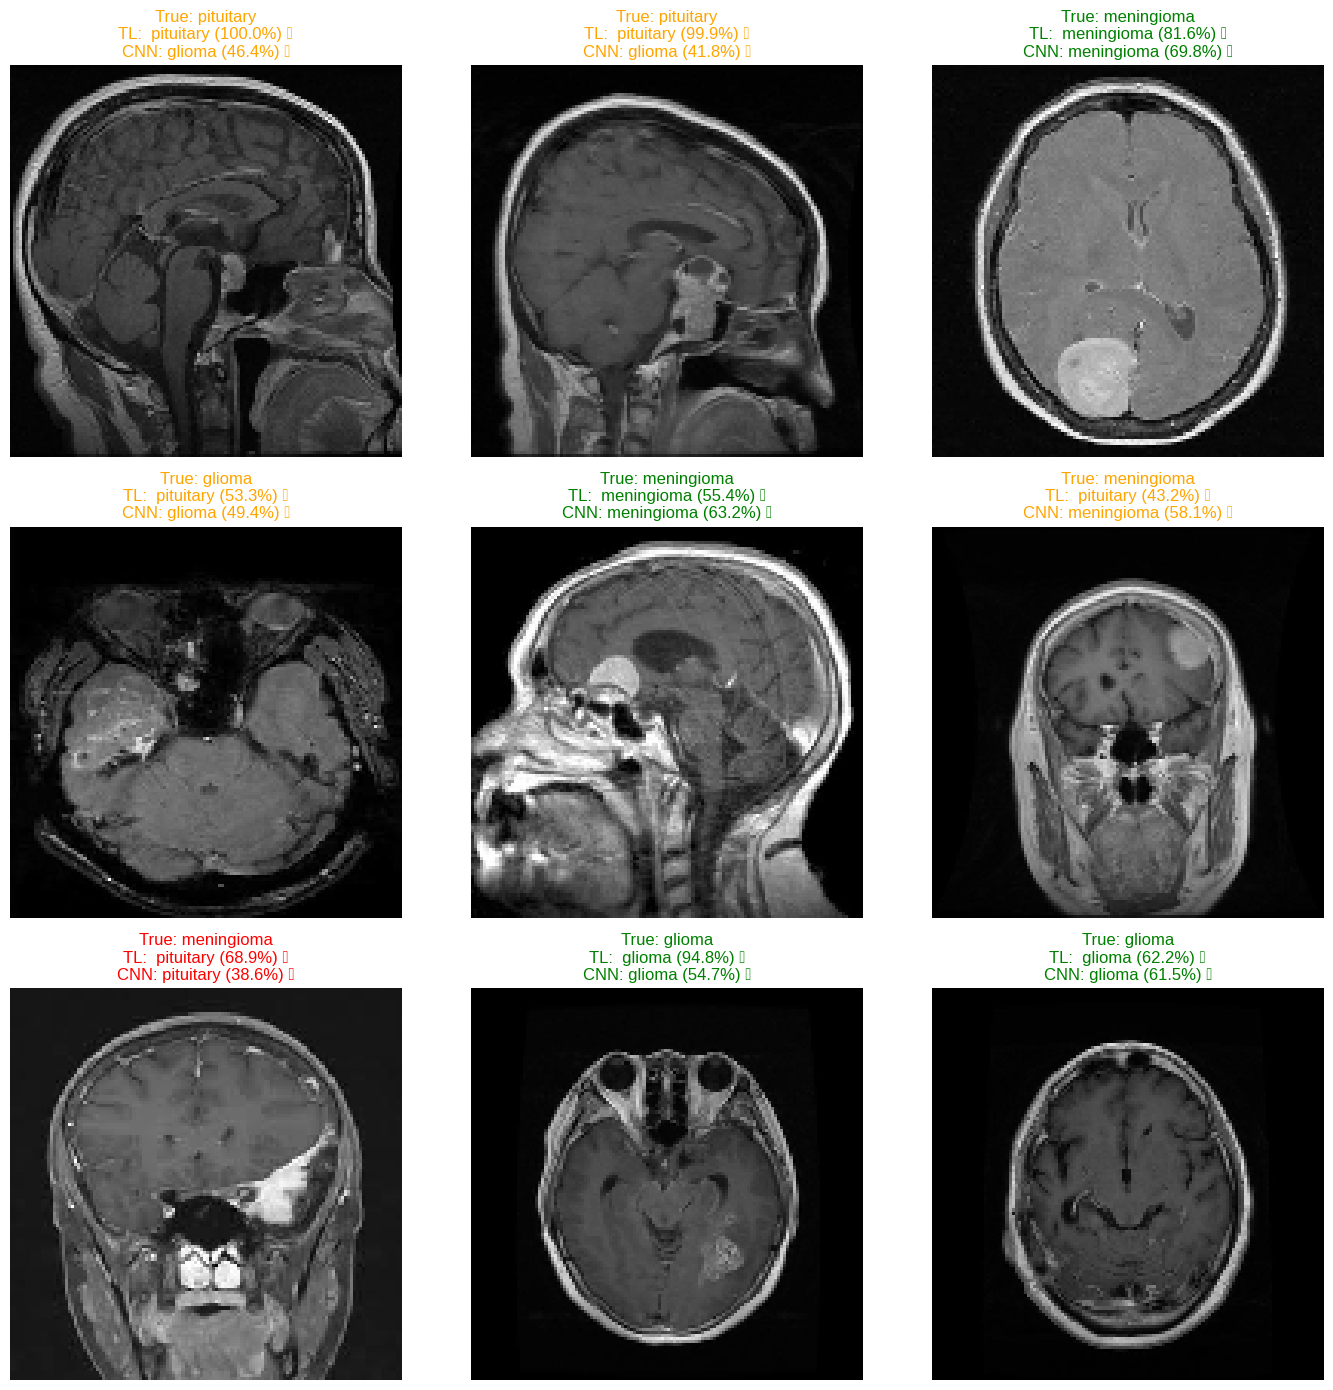

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# ---- choose a few sample images from the SAME test set ----
num_samples = 9
total = len(test_generator.filepaths)
idxs = np.random.choice(total, size=min(num_samples, total), replace=False)

class_names = list(test_generator.class_indices.keys())
true_class_ids = test_generator.classes  # aligned with test_generator.filepaths
filepaths = [test_generator.filepaths[i] for i in idxs]

# ---- model input sizes ----
cnn_h, cnn_w = baseline_model.input_shape[1], baseline_model.input_shape[2]
tl_h, tl_w   = tl_model.input_shape[1], tl_model.input_shape[2]

# ---- load images once from disk, then create CNN + TL inputs ----
cnn_batch = []
tl_batch = []
display_imgs = []

for fp in filepaths:
    # Display image (use TL size so it looks nice)
    img_disp = tf.keras.utils.load_img(fp, color_mode="rgb", target_size=(tl_h, tl_w))
    img_disp = tf.keras.utils.img_to_array(img_disp).astype(np.float32)
    display_imgs.append(img_disp)

    # Baseline CNN expects GRAYSCALE + [0,1]
    img_cnn = tf.keras.utils.load_img(fp, color_mode="grayscale", target_size=(cnn_h, cnn_w))
    img_cnn = tf.keras.utils.img_to_array(img_cnn).astype(np.float32) / 255.0
    cnn_batch.append(img_cnn)

    # TL expects RGB + preprocess_input (expects [0,255] then normalizes internally)
    img_tl = tf.keras.utils.load_img(fp, color_mode="rgb", target_size=(tl_h, tl_w))
    img_tl = tf.keras.utils.img_to_array(img_tl).astype(np.float32)
    tl_batch.append(img_tl)

cnn_in = np.stack(cnn_batch, axis=0)
tl_in  = preprocess_input(np.stack(tl_batch, axis=0))
display_imgs = np.stack(display_imgs, axis=0)

# ---- predict ----
cnn_probs = baseline_model.predict(cnn_in, verbose=0)
tl_probs  = tl_model.predict(tl_in, verbose=0)

cnn_pred = np.argmax(cnn_probs, axis=1)
tl_pred  = np.argmax(tl_probs, axis=1)

cnn_conf = cnn_probs[np.arange(len(cnn_probs)), cnn_pred] * 100
tl_conf  = tl_probs[np.arange(len(tl_probs)), tl_pred] * 100

true_labels = [class_names[int(true_class_ids[i])] for i in idxs]

# ---- plot ----
cols = 3
rows = int(np.ceil(len(filepaths) / cols))
plt.figure(figsize=(14, 14))

for k in range(len(filepaths)):
    ax = plt.subplot(rows, cols, k + 1)

    img_show = np.clip(display_imgs[k] / 255.0, 0, 1)
    ax.imshow(img_show)
    ax.axis("off")

    true_label = true_labels[k]
    cnn_label = class_names[cnn_pred[k]]
    tl_label  = class_names[tl_pred[k]]

    cnn_ok = (cnn_label == true_label)
    tl_ok  = (tl_label == true_label)

    # Title coloring: green if both correct, orange if one, red if neither
    if cnn_ok and tl_ok:
        color = "green"
    elif cnn_ok or tl_ok:
        color = "orange"
    else:
        color = "red"

    ax.set_title(
        f"True: {true_label}\n"
        f"TL:  {tl_label} ({tl_conf[k]:.1f}%) {'✓' if tl_ok else '✗'}\n"
        f"CNN: {cnn_label} ({cnn_conf[k]:.1f}%) {'✓' if cnn_ok else '✗'}",
        color=color
    )

plt.tight_layout()
plt.show()